# Kiểm kê dataset PCB

Notebook này kiểm kê dataset định dạng YOLO trong `data/raw/`, không chỉnh sửa ảnh hoặc file nhãn. Kết quả được ghi vào `results/dataset_statistics.csv` và `results/class_distribution.png`.

## Giải nén dataset

Chỉ chạy cell giải nén sau khi file ZIP đã tải hoàn tất. Hàm kiểm tra Zip Slip trước khi giải nén để không cho phép archive ghi file ra ngoài thư mục đích.

In [1]:
from pathlib import Path
import zipfile

import matplotlib.pyplot as plt
import pandas as pd


def get_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'data').is_dir() and (candidate / 'configs').is_dir():
            return candidate
    raise RuntimeError('Không tìm thấy thư mục gốc của dự án.')


PROJECT_ROOT = get_project_root(Path.cwd().resolve())
RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
RESULTS_DIR = PROJECT_ROOT / 'results'
CLASSES = [
    'missing_hole',
    'mouse_bite',
    'open_circuit',
    'short',
    'spur',
    'spurious_copper',
]


In [2]:
def extract_zip_safely(zip_path: Path, destination: Path) -> None:
    """Giải nén ZIP vào destination sau khi chặn đường dẫn Zip Slip."""
    zip_path = Path(zip_path)
    destination = Path(destination)
    if not zipfile.is_zipfile(zip_path):
        raise ValueError(f'{zip_path} không phải file ZIP hợp lệ hoặc chưa tải xong.')

    destination.mkdir(parents=True, exist_ok=True)
    resolved_destination = destination.resolve()
    with zipfile.ZipFile(zip_path) as archive:
        for member in archive.infolist():
            target = (destination / member.filename).resolve()
            if not target.is_relative_to(resolved_destination):
                raise ValueError(f'Đường dẫn không an toàn trong ZIP: {member.filename}')
        archive.extractall(destination)


ZIP_PATH = RAW_DIR / 'pcb-defect-detection-dataset.zip'
EXTRACTED_DIRS = [
    RAW_DIR / 'DeepPCB',
    RAW_DIR / 'PKU-Market-PCB(Data enhanced version)',
]
if not all(path.is_dir() for path in EXTRACTED_DIRS):
    extract_zip_safely(ZIP_PATH, RAW_DIR)


## Kiểm kê ảnh và nhãn

Hàm dưới đây hỗ trợ cấu trúc YOLO có thư mục `images/` và `labels/`, đồng thời hỗ trợ ảnh và nhãn nằm cùng thư mục. Mỗi dòng không rỗng trong file nhãn được xem là một bounding box YOLO. Phần thống kê dùng PKU-Market-PCB vì sáu lớp trong `configs/base.yaml` thuộc tập này.

In [3]:
IMAGE_SUFFIXES = {'.bmp', '.jpeg', '.jpg', '.png', '.tif', '.tiff', '.webp'}


def get_label_path(image_path: Path, dataset_root: Path) -> Path | None:
    relative_image = image_path.relative_to(dataset_root)
    candidates = [image_path.with_suffix('.txt')]
    if 'images' in relative_image.parts:
        image_index = relative_image.parts.index('images')
        label_relative = Path(
            *relative_image.parts[:image_index],
            'labels',
            *relative_image.parts[image_index + 1:],
        ).with_suffix('.txt')
        candidates.insert(0, dataset_root / label_relative)
    return next((path for path in candidates if path.is_file()), None)


def count_boxes(label_path: Path) -> list[int]:
    class_ids = []
    for line_number, line in enumerate(label_path.read_text(encoding='utf-8').splitlines(), start=1):
        if not line.strip():
            continue
        fields = line.split()
        if len(fields) != 5:
            raise ValueError(f'{label_path}:{line_number} không phải nhãn YOLO hợp lệ.')
        class_id = int(fields[0])
        if class_id not in range(len(CLASSES)):
            raise ValueError(f'{label_path}:{line_number} có class id ngoài phạm vi: {class_id}')
        class_ids.append(class_id)
    return class_ids


In [4]:
DATASET_DIR = RAW_DIR / 'PKU-Market-PCB(Data enhanced version)'
if not DATASET_DIR.is_dir():
    raise FileNotFoundError(
        f'Không tìm thấy {DATASET_DIR}. Hãy tải và giải nén dataset trước khi kiểm kê.'
    )

image_paths = sorted(
    path for path in DATASET_DIR.rglob('*')
    if path.is_file() and path.suffix.lower() in IMAGE_SUFFIXES
)
label_paths = sorted(
    path for path in DATASET_DIR.rglob('*.txt') if path.name != 'Class.txt'
)
matched_pairs = [(image, get_label_path(image, DATASET_DIR)) for image in image_paths]
matched_pairs = [(image, label) for image, label in matched_pairs if label is not None]

boxes_per_class = [0] * len(CLASSES)
boxes_per_image = {image: 0 for image in image_paths}
for image_path, label_path in matched_pairs:
    class_ids = count_boxes(label_path)
    boxes_per_image[image_path] = len(class_ids)
    for class_id in class_ids:
        boxes_per_class[class_id] += 1

total_images = len(image_paths)
box_counts = list(boxes_per_image.values())
min_image = min(boxes_per_image, key=boxes_per_image.get, default=None)
max_image = max(boxes_per_image, key=boxes_per_image.get, default=None)

summary_rows = [
    ('dataset', 'total_images', '', total_images),
    ('dataset', 'total_label_files', '', len(label_paths)),
    ('dataset', 'matched_image_label_pairs', '', len(matched_pairs)),
    ('dataset', 'boxes_per_image_mean', '', sum(box_counts) / total_images if total_images else 0),
    ('dataset', 'fewest_boxes', str(min_image.relative_to(DATASET_DIR)) if min_image else '', min(box_counts, default=0)),
    ('dataset', 'most_boxes', str(max_image.relative_to(DATASET_DIR)) if max_image else '', max(box_counts, default=0)),
]
summary_rows.extend(
    ('class_distribution', 'bounding_boxes', class_name, box_count)
    for class_name, box_count in zip(CLASSES, boxes_per_class)
)
statistics = pd.DataFrame(summary_rows, columns=['category', 'metric', 'class', 'value'])
statistics


,category,metric,class,value
0,dataset,total_images,,4837.000000
1,dataset,total_label_files,,3504.000000
2,dataset,matched_image_label_pairs,,3504.000000
3,dataset,boxes_per_image_mean,,2.982427
4,dataset,fewest_boxes,train/images/train1/01_missing_hole_01.jpg,0.000000
5,dataset,most_boxes,test/images/01_short_09_1.jpg,6.000000
6,class_distribution,bounding_boxes,missing_hole,2434.000000
7,class_distribution,bounding_boxes,mouse_bite,2410.000000
8,class_distribution,bounding_boxes,open_circuit,2338.000000
9,class_distribution,bounding_boxes,short,2396.000000


## Xuất kết quả

CSV dùng định dạng dài: các dòng `dataset` lưu thống kê tổng quát, còn các dòng `class_distribution` lưu số bounding box theo lớp.

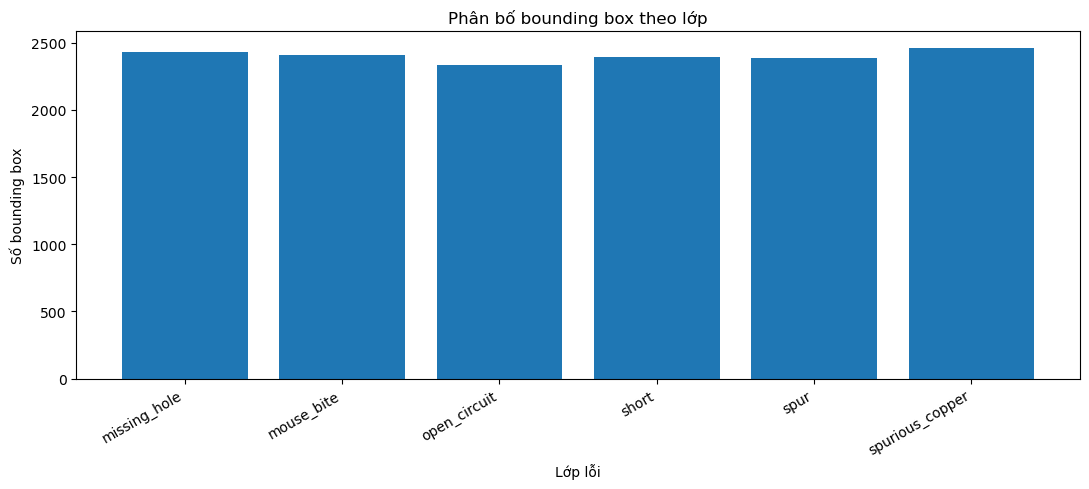

In [5]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
statistics.to_csv(RESULTS_DIR / 'dataset_statistics.csv', index=False)

plt.figure(figsize=(11, 5))
plt.bar(CLASSES, boxes_per_class, color='#1f77b4')
plt.title('Phân bố bounding box theo lớp')
plt.xlabel('Lớp lỗi')
plt.ylabel('Số bounding box')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'class_distribution.png', dpi=150)
plt.show()
